# Sprint 15: Computer Vision — Facial Age Detection

**Student:** Dr. Danisha L. Thomas  
**Date:** April 6, 2026  
**Project:** Good Seed Supermarket Age Verification Model

---

## Project Overview

### Objective
Good Seed, a supermarket chain, seeks to explore whether computer vision can assist in complying with alcohol laws by verifying customer age at the point of sale. This project builds and evaluates a convolutional neural network to predict a person's real age from a facial photograph.

### Data Description
The dataset consists of **7,591 labeled facial images** sourced from the ChaLearn Looking at People competition. Each image is paired with a record in `labels.csv` containing two fields — `file_name` and `real_age`. Images are stored in `/datasets/faces/final_files/` and resized to **224x224 pixels** to meet ResNet50 input requirements.

### Expected Outcomes
- Perform exploratory data analysis (EDA) on the image dataset, including age distribution and sample visualization
- Build a regression model using a **ResNet50 backbone** with transfer learning to predict customer age
- Achieve a validation **MAE ≤ 8 years**, the benchmark set for production viability
- Assess whether the model's accuracy is sufficient for real-world age verification use cases

## Initialization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

## Load Data

The dataset is stored in the /datasets/faces/ folder, there you can find

The final_files folder with 7.6k photos
The labels.csv file with labels, with two columns: file_name and real_age
Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')

In [4]:
# Data Overview
print("Dataset Shape:", labels.shape)
print()
print(labels.head())
print()

Dataset Shape: (7591, 2)

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17



## EDA

In [5]:
labels['real_age'].describe()

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

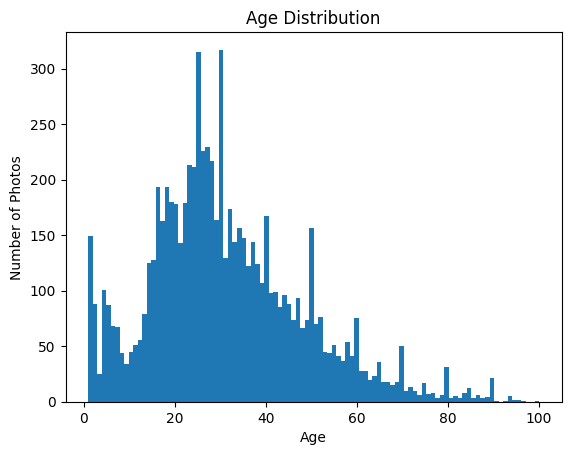

In [13]:
# hitsogram

plt.hist(labels['real_age'], bins=100)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Photos')
plt.show()

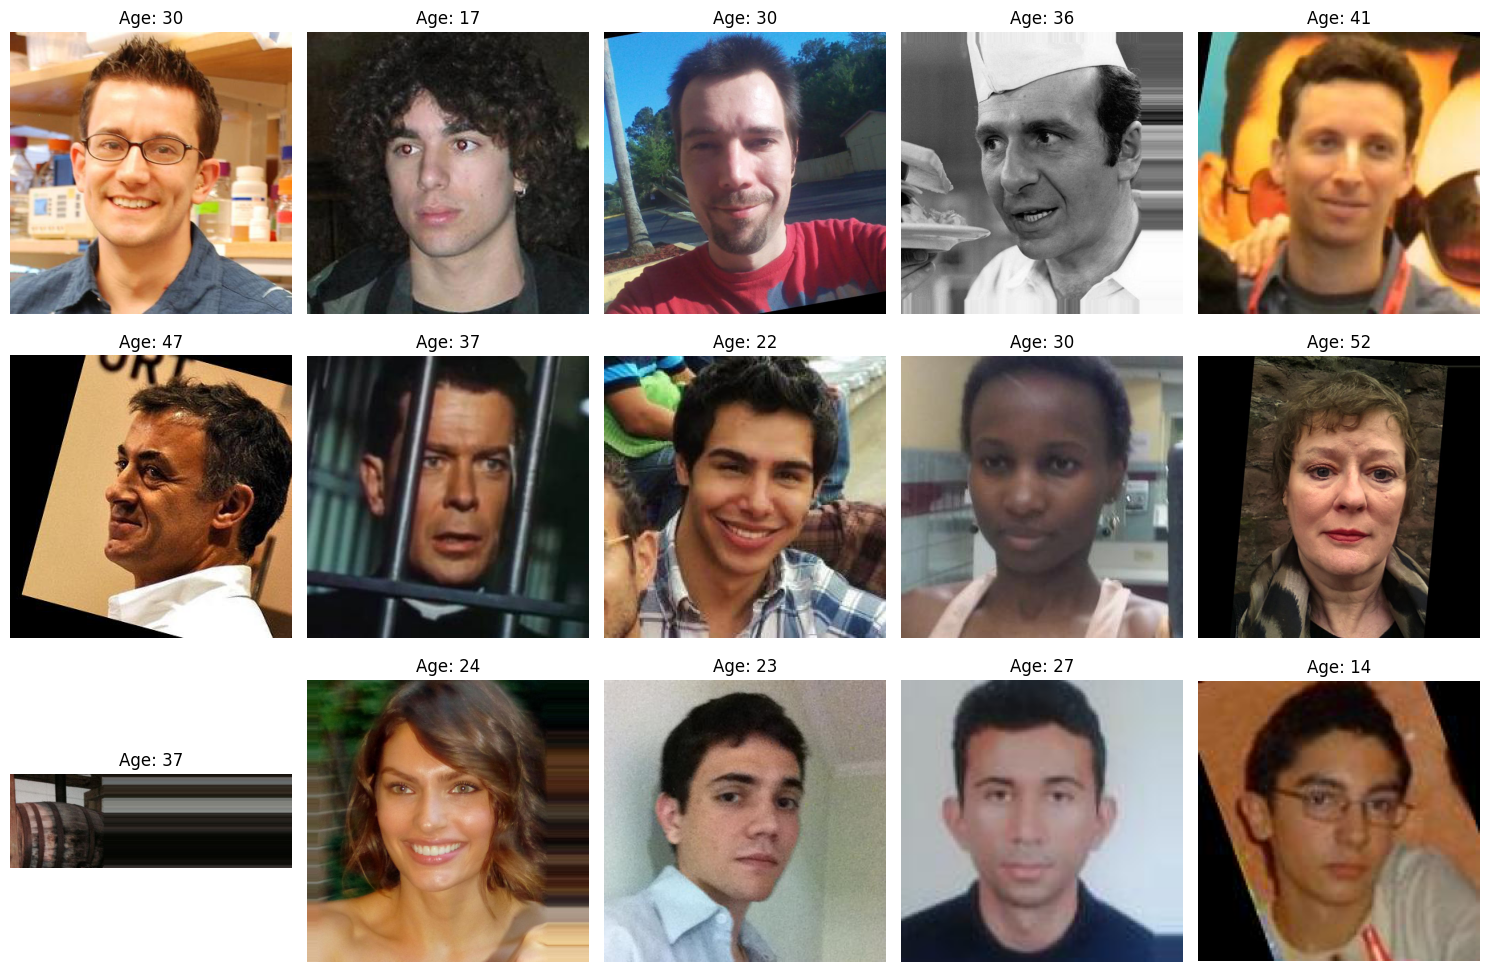

In [14]:
# sample 15 images

sample = labels.sample(15)

# set up grid
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

# loop through sample
for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open('/datasets/faces/final_files/' + row['file_name'])
    axes[i].imshow(img)
    axes[i].set_title(f"Age: {row['real_age']}")
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

### Findings

The histogram shows class imbalance, with most images clustered in the 25-40 age range. Although the sample of images demonstrates a fairly even distribution of photo ages, the concentration in this age group confirms the imbalance. Additionally, the image quality varies significantly, with some images in black and white, others blurry, and one with a square cutout. These factors may cause model inaccuracies and bias, leading to poor performance when predicting the ages of younger and older individuals.

**Addressing Class Imbalance:**
To improve model performance, the dataset could be enhanced by collecting additional images across underrepresented age groups to create a more balanced distribution. Image quality could also be standardized to reduce variability in lighting and resolution, which would provide the model with more consistent training data.

## Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [ ]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
def load_train(path):
    
    """
    It loads the train part of dataset from path
    """
    
    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, validation_split=0.2)
    
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345,
        subset='training'
    )
   
    return train_gen_flow

In [ ]:
def load_test(path):
    
    """
    It loads the validation/test part of dataset from path
    """
    
    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',  
        seed=12345,
        subset='validation'
    )
   
    return test_gen_flow

In [ ]:
def create_model(input_shape):
    
    """
    It defines the model
    """
    
    backbone = ResNet50(weights='imagenet', 
                        input_shape=input_shape,
                        include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

In [ ]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Trains the model given the parameters
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
        
    if validation_steps is None:
        validation_steps = len(test_data)
    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model

### Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [ ]:
# prepare a script to run on the GPU platform

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### Output

<pre>
Epoch 1/20
356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921
Epoch 2/20
356/356 - 35s - loss: 76.8372 - mae: 6.6707 - val_loss: 127.6357 - val_mae: 8.6035
Epoch 3/20
356/356 - 35s - loss: 69.9428 - mae: 6.3992 - val_loss: 91.1531 - val_mae: 7.4454
Epoch 4/20
356/356 - 35s - loss: 64.4249 - mae: 6.1407 - val_loss: 124.0287 - val_mae: 8.3481
Epoch 5/20
356/356 - 35s - loss: 52.8486 - mae: 5.5913 - val_loss: 109.1004 - val_mae: 8.2192
Epoch 6/20
356/356 - 35s - loss: 46.3094 - mae: 5.2223 - val_loss: 85.1038 - val_mae: 7.0332
Epoch 7/20
356/356 - 35s - loss: 38.2617 - mae: 4.7951 - val_loss: 92.0900 - val_mae: 7.3359
Epoch 8/20
356/356 - 35s - loss: 37.4804 - mae: 4.7402 - val_loss: 80.0016 - val_mae: 6.7239
Epoch 9/20
356/356 - 35s - loss: 33.5237 - mae: 4.4271 - val_loss: 83.2579 - val_mae: 6.8529
Epoch 10/20
356/356 - 35s - loss: 28.5170 - mae: 4.1411 - val_loss: 83.5056 - val_mae: 6.9629
Epoch 11/20
356/356 - 35s - loss: 27.0142 - mae: 3.9700 - val_loss: 92.1290 - val_mae: 7.1866
Epoch 12/20
356/356 - 35s - loss: 27.4564 - mae: 4.0428 - val_loss: 185.6307 - val_mae: 11.4591
Epoch 13/20
356/356 - 35s - loss: 23.7961 - mae: 3.7407 - val_loss: 92.3429 - val_mae: 7.2467
Epoch 14/20
356/356 - 35s - loss: 24.6167 - mae: 3.8116 - val_loss: 92.4542 - val_mae: 7.1401
Epoch 15/20
356/356 - 35s - loss: 22.2604 - mae: 3.6746 - val_loss: 82.5822 - val_mae: 6.7841
Epoch 16/20
356/356 - 35s - loss: 20.1899 - mae: 3.4430 - val_loss: 86.3830 - val_mae: 6.8304
Epoch 17/20
356/356 - 35s - loss: 17.3425 - mae: 3.2205 - val_loss: 78.4369 - val_mae: 6.6419
Epoch 18/20
356/356 - 35s - loss: 16.5249 - mae: 3.1295 - val_loss: 81.7731 - val_mae: 6.7226
Epoch 19/20
356/356 - 35s - loss: 16.6140 - mae: 3.1421 - val_loss: 80.9727 - val_mae: 6.9908
Epoch 20/20
356/356 - 35s - loss: 17.0187 - mae: 3.1785 - val_loss: 93.4115 - val_mae: 7.6512
</pre>

## Conclusions

**Model Performance and Alcohol Age Restriction/Use Case**

Overall, computer vision can help this customer to a degree.  If the customer is trying to determine age to sell alcohol to customers, if they are older, being within a 7 to 8 year range is fine. However, if the person is younger, say, like 18, then being off by 7 to 8 years is problematic (i.e., illegal). 

**Practical Applications**

Other practical tasks could include monitoring trends and the popularity of goods by consumer age to help the company with its purchasing decisions. They could tell what older customers liked, versus what younger customers liked, and vice versa.

**Key Takeaways and Recommendations**

The most important takeaways for this project are that determining age from images could be used in a variety of fields, but should be done with caution. The model tended to have the highest concentration of images between ages 25 and 40, making it difficult to predict older (i.e., over 65) and younger (i.e., under 20) ages. Those who want to use computer vision should do so with these issues in mind, or run a deeper analysis (i.e., a larger number of images) to compare results and improve the model's predictions, because the MAE decreased as the number of images increased.


# Checklist

- [x]  Notebook was opened
- [x]  The code is error free
- [x]  The cells with code have been arranged by order of execution
- [x]  The exploratory data analysis has been performed
- [x]  The results of the exploratory data analysis are presented in the final notebook
- [x]  The model's MAE score is not higher than 8
- [x]  The model training code has been copied to the final notebook
- [x]  The model training output has been copied to the final notebook
- [x]  The findings have been provided based on the results of the model training